In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx

In [3]:
# MNIST data
from datasets import load_dataset
import numpy as np

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


In [28]:
import scipy

train_data = dataset["train"]   

def train_data_generator(batch_size=256):
    key = jax.random.key(0)
    while True:
        key, subkey, subkey2 = jax.random.split(key, 3)
        idx = np.random.randint(0, len(train_data), size=batch_size)
        
        xs_batch = train_data[idx]["image"] / 256
        # Rotate a bit
        xs_batch = scipy.ndimage.rotate(xs_batch, np.random.uniform() * 10, axes=(1, 2), reshape=False)
        
        # Resize to 10x10
        #xs_batch = jax.image.resize(xs_batch, (batch_size, 10, 10), method='bilinear')
        
        # Quantize
        xs_batch = jnp.array(xs_batch, dtype=jnp.float32).reshape(batch_size, 28, 28, 1)
        xs_batch += jax.random.uniform(subkey2, xs_batch.shape) / 255  # Uniform dequantization
        # Rescale to [-1, 1]
        xs_batch = jnp.nan_to_num(xs_batch)
        
        yield xs_batch.reshape(batch_size, -1, 1)

datagenerator = train_data_generator()

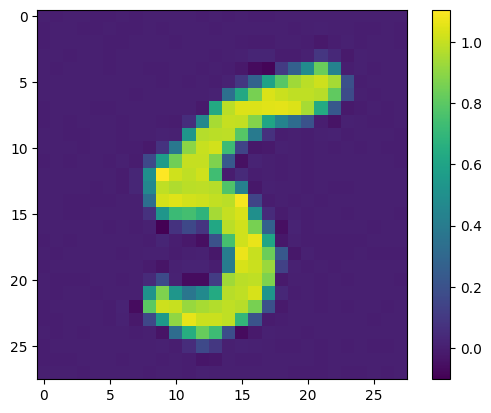

In [29]:
images = next(datagenerator)
plt.imshow(images[0].reshape(28,28))
plt.colorbar()

In [30]:
from probjax.nn.nets.transformer import PosEmbed, Transformer
from probjax.nn.bijective import rational_quadratic_spline,learnable_mixture_cdf, piecwise_linear_spline,rational_quadratic_spline_and_logdets, inv_rational_quadratic_spline
from probjax.core import inverse_and_logabsdet
from functools import partial

NUM_BINS=20


cdf_model = partial(piecwise_linear_spline,range_min_x=0., range_max_x=1., range_min_y= 0., range_max_y=1., bounded=True)
cdf_model = partial(rational_quadratic_spline_and_logdets,range_min_x=0., range_max_x=1., range_min_y= 0., range_max_y=1., bounded=True, min_bin_size=1e-3)
icdf_model = partial(inv_rational_quadratic_spline,range_min_x=0., range_max_x=1., range_min_y= 0., range_max_y=1., bounded=True)

class Model(nnx.Module, experimental_pytree=True):

    num_heads: int = 4
    num_layers: int = 6
    dim: int
    widening_factor: int = 3
    attn_size: int = 20
    num_params:int =  3*NUM_BINS 

    def __init__(self, dim,rngs, dropout_rate=None):
        self.embed = nnx.Linear(1, dim, rngs=rngs)
        self.pos_embed = PosEmbed(dim,rngs=rngs)
        self.transformer = Transformer(dim, self.num_heads,self.num_heads,self.attn_size, widening_factor=self.widening_factor,rngs=rngs, dropout_rate=dropout_rate)
        self.output = nnx.Linear(dim, self.num_params, rngs=rngs, kernel_init=nnx.initializers.zeros)
        self.start_token = nnx.Param(jnp.zeros((1,dim)))

    def __call__(self, x, decode=False, deterministic=False):
        x = self.embed(x)
        x = self.pos_embed(x)
        # Autoregressive mask 
        start_token = self.start_token.value
        start_token = jnp.repeat(start_token[None,...], x.shape[0], axis=0)
        x = jnp.concatenate([start_token, x], axis=1)
        mask = jnp.tril(jnp.ones((x.shape[-2], x.shape[-2])))
        x = self.transformer(x, mask=mask, deterministic=deterministic, decode=decode)
        params = self.output(x)
        return params[..., :-1, :]
    
    
    def loss(self, params, x):
        nnx.update(self, params)
        def log_prob(params, x):
            _cdf = partial(cdf_model, params)
            x = jnp.clip(x, 0., 1.)
            _, logdet = _cdf(x)
            return logdet
        
        params = self(x)
        loss = - jax.vmap(jax.vmap(log_prob))(params, x)
        loss = jnp.nan_to_num(loss)
        loss = jnp.sum(loss, axis=(-2,-1))
        return jnp.mean(loss)
    

    def transform(self, x):
        params = self(x)
        icdf = lambda p,x: inverse_and_logabsdet(partial(cdf_model, p))(x)[0]
        return jax.vmap(jax.vmap(icdf))(params, x)
            
        
model = Model(300, rngs=nnx.Rngs(0))
params = nnx.state(model, nnx.Param)

300


In [31]:
# Visualize initial model denoising
x = next(datagenerator)

y = model.loss(params,x)
y

(256, 785, 300)
(256, 785, 300)
(256, 785, 300)
(256, 785, 300)


Array(0., dtype=float32)

In [32]:
# def loss_fn(params, x, rng):
#     return model.loss_masked(params, x, rng)

# AR loss
def loss_fn(params, x, _):
    return model.loss(params, x)

In [54]:
from functools import partial
import optax

schedule = optax.cosine_onecycle_schedule(10*1000, 5e-4)
opt = optax.chain(optax.adaptive_grad_clip(50.), optax.adam(schedule))
params_per_device = jax.tree_util.tree_map(
    lambda p: jnp.stack([p] * jax.local_device_count(), axis=0), 
    params
)
opt_state = jax.vmap(opt.init)(params_per_device)

@partial(jax.pmap, axis_name='batch')
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, x, rng)
    grads = jax.tree_map(lambda x: jnp.nan_to_num(x), grads)

    # Average across all replicas on the 'batch' axis
    loss = jax.lax.pmean(loss, axis_name='batch')
    grads = jax.lax.pmean(grads, axis_name='batch')

    updates, opt_state = opt.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    params = jax.tree_map(lambda x: jnp.nan_to_num(x), params)

    return params, opt_state, loss

def train_step(params, opt_state, xs, rng):
    # Reshape xs to split across devices
    xs_split = jnp.reshape(xs, (jax.local_device_count(), -1, *xs.shape[1:]))
    rng = jax.random.split(rng, jax.local_device_count())

    params, opt_state, losses = update(params, opt_state, xs_split, rng)
    return params, opt_state, jnp.mean(losses)


In [55]:
key = jax.random.key(4)

In [56]:
# Example training iteration
for i in range(10):
    l = 0.
    for j in range(1000): 
        key, key_data, key_loss = jax.random.split(key, 3)
        xs = next(datagenerator)
        params_per_device, opt_state, loss = train_step(params_per_device, opt_state, xs, key_loss)
        l += loss
    print(l/1000)

(256, 785, 300)
(256, 785, 300)
(256, 785, 300)
(256, 785, 300)
-3598.6748
-3568.137
-3555.2546
-3560.1165
-3574.3357
-3588.092
-3603.4167
1.3292279e+33
-3632.3062
2.6584558e+33


In [57]:
params = jax.tree_map(lambda x: x[0], params_per_device)
nnx.update(model, params)

In [58]:
spline_params = model(x)

(256, 785, 300)
(256, 785, 300)
(256, 785, 300)
(256, 785, 300)


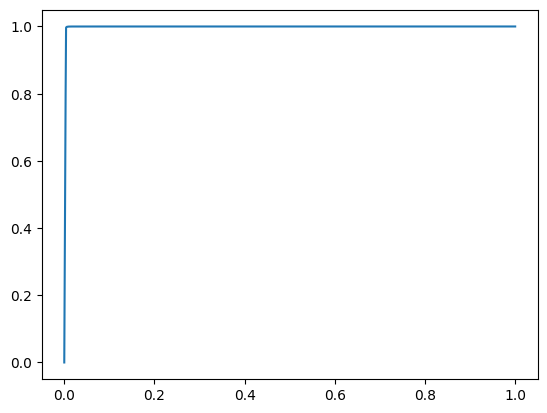

In [59]:
spine_p = spline_params[0,22,:]
cdf = partial(cdf_model, spine_p)
#icdf = lambda p: inverse(cdf)(p)
ts = jnp.linspace(0,1,1000)
ys = jax.vmap(cdf)(ts)[0]
p = jnp.diff(ys)/jnp.diff(ts)
plt.plot(ts, ys)
#ts_rec = jax.vmap(icdf)(ys)
#plt.plot(ts, ts_rec)
#plt.plot(ts[1:], p)


In [60]:
T = xs.shape[1] 
d = jnp.sqrt(xs.shape[1]).astype(jnp.int32)
def naive_autoregressive_decoding(key, T=T):
    x = jax.random.uniform(key,(1, T,1), dtype=jnp.float32)
    def scan_fn(carry, k):
        x, i = carry
        params = model(x)
        p_i = params[0,i]
        u_i = x[0, i]
        icdf = partial(icdf_model,p_i)
        x_i = icdf(u_i)[0]
        x = x.at[0, i].set(x_i)
        return (x, i+1), None
    keys = jax.random.split(key, (T,))
    x, _ = jax.lax.scan(scan_fn, (x, 0), keys)

    return x[0].squeeze(0)

In [61]:
xs.shape

(256, 784, 1)

In [62]:
keys = jax.random.split(jax.random.key(0), (100,))

In [63]:
samples = jax.vmap(naive_autoregressive_decoding)(keys)

(1, 785, 300)
(1, 785, 300)
(1, 785, 300)
(1, 785, 300)


In [64]:
img = samples.reshape(10, 10, d, d).transpose(0, 2, 1, 3).reshape(10*d, 10*d)

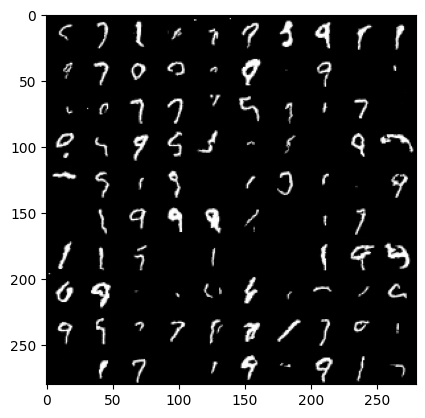

In [65]:
plt.imshow(img, cmap="gray")